<a href="https://colab.research.google.com/github/napat-sri/airflow-training-lab/blob/main/E36_Data_Eng_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Project:** การจัดการข้อมูลอุบัติเหตุทางการบินทั่วโลก เพื่อวิเคราะห์แนวโน้มความปลอดภัย

**ชื่อ-นามสกุล:** นายณภัทร ศรีวิโรจน์  
**รหัส** E36  
**หน่วยงาน:** ศูนย์ซอฟต์แวร์กองทัพอากาศ



##Phase 0 - Data Collection

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import kagglehub

# Download dataset
path = kagglehub.dataset_download("cgurkan/airplane-crash-data-since-1908")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'airplane-crash-data-since-1908' dataset.
Path to dataset files: /kaggle/input/airplane-crash-data-since-1908


In [3]:
# Create DataFrame

plane_path = path + "/Airplane_Crashes_and_Fatalities_Since_1908_20190820105639.csv"

plane_df = pd.read_csv(plane_path)
print("Reading from: ", plane_path)

Reading from:  /kaggle/input/airplane-crash-data-since-1908/Airplane_Crashes_and_Fatalities_Since_1908_20190820105639.csv


In [4]:
# Data Insight

print("Dataset shape:", plane_df.shape)
print("\nColumns: ", plane_df.columns.tolist())

print("\nDataset: ")
display(plane_df.head())

Dataset shape: (4967, 17)

Columns:  ['Date', 'Time', 'Location', 'Operator', 'Flight #', 'Route', 'AC Type', 'Registration', 'cn/ln', 'Aboard', 'Aboard Passangers', 'Aboard Crew', 'Fatalities', 'Fatalities Passangers', 'Fatalities Crew', 'Ground', 'Summary']

Dataset: 


,Date,Time,Location,Operator,Flight #,Route,AC Type,Registration,cn/ln,Aboard,Aboard Passangers,Aboard Crew,Fatalities,Fatalities Passangers,Fatalities Crew,Ground,Summary
0,09/17/1908,17:18,"Fort Myer, Virginia",Military - U.S. Army,NaN,Demonstration,Wright Flyer III,NaN,1,2.0,1.0,1.0,1.0,1.0,0.0,0.0,"During a demonstration flight, a U.S. Army fly..."
1,09/07/1909,NaN,"Juvisy-sur-Orge, France",NaN,NaN,Air show,Wright Byplane,SC1,NaN,1.0,0.0,1.0,1.0,0.0,0.0,0.0,Eugene Lefebvre was the first pilot to ever be...
2,07/12/1912,06:30,"Atlantic City, New Jersey",Military - U.S. Navy,NaN,Test flight,Dirigible,NaN,NaN,5.0,0.0,5.0,5.0,0.0,5.0,0.0,First U.S. dirigible Akron exploded just offsh...
3,08/06/1913,NaN,"Victoria, British Columbia, Canada",Private,NaN,NaN,Curtiss seaplane,NaN,NaN,1.0,0.0,1.0,1.0,0.0,1.0,0.0,The first fatal airplane accident in Canada oc...
4,09/09/1913,18:30,Over the North Sea,Military - German Navy,NaN,NaN,Zeppelin L-1 (airship),NaN,NaN,20.0,NaN,NaN,14.0,NaN,NaN,0.0,The airship flew into a thunderstorm and encou...


##Phase 1 - Data Cleaning

In [5]:
plane_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4967 entries, 0 to 4966
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Date                   4967 non-null   object 
 1   Time                   3457 non-null   object 
 2   Location               4963 non-null   object 
 3   Operator               4957 non-null   object 
 4   Flight #               1315 non-null   object 
 5   Route                  4192 non-null   object 
 6   AC Type                4952 non-null   object 
 7   Registration           4694 non-null   object 
 8   cn/ln                  4299 non-null   object 
 9   Aboard                 4949 non-null   float64
 10  Aboard Passangers      4738 non-null   float64
 11  Aboard Crew            4741 non-null   float64
 12  Fatalities             4959 non-null   float64
 13  Fatalities Passangers  4725 non-null   float64
 14  Fatalities Crew        4726 non-null   float64
 15  Grou

In [6]:
plane_df.describe()

,Aboard,Aboard Passangers,Aboard Crew,Fatalities,Fatalities Passangers,Fatalities Crew,Ground
count,4949.000000,4738.000000,4741.000000,4959.000000,4725.000000,4726.000000,4926.000000
mean,31.088301,26.898691,4.479646,22.338173,19.017566,3.579348,1.728177
std,45.438282,44.010591,3.489021,35.026176,34.114849,3.170223,55.708966
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,7.000000,3.000000,2.000000,4.000000,1.000000,2.000000,0.000000
50%,16.000000,12.000000,4.000000,11.000000,8.000000,3.000000,0.000000
75%,35.000000,30.000000,6.000000,25.000000,21.000000,5.000000,0.000000
max,644.000000,614.000000,61.000000,583.000000,560.000000,46.000000,2750.000000


### 1. Missing values

In [7]:
# Count missing values
missing = plane_df.isnull().sum()
missing_percent = (missing / len(plane_df) * 100).round(2)

missing_report = pd.DataFrame({
    "Missing count: ": missing,
    "Missing %: ": missing_percent
})

print(missing_report)

                       Missing count:   Missing %: 
Date                                 0         0.00
Time                              1510        30.40
Location                             4         0.08
Operator                            10         0.20
Flight #                          3652        73.53
Route                              775        15.60
AC Type                             15         0.30
Registration                       273         5.50
cn/ln                              668        13.45
Aboard                              18         0.36
Aboard Passangers                  229         4.61
Aboard Crew                        226         4.55
Fatalities                           8         0.16
Fatalities Passangers              242         4.87
Fatalities Crew                    241         4.85
Ground                              41         0.83
Summary                             64         1.29


In [8]:
# High percent missings
high_missing = ['Flight #', 'Route', 'cn/ln']

for c in high_missing:
  if c in plane_df.columns:
    plane_df[c] = plane_df[c].fillna("Unknown")
    print(f"fill 'Unknown in {c}")

fill 'Unknown in Flight #
fill 'Unknown in Route
fill 'Unknown in cn/ln


In [9]:
# Time missing (Unknown exact time)
plane_df['Time'] = plane_df['Time'].fillna('00:00')
print("fill '00:00' in Time")

fill '00:00' in Time


In [10]:
# 'Ground' missings -> 0
plane_df['Ground'] = pd.to_numeric(plane_df['Ground']).fillna(0)
print("fill '0' in Ground")

fill '0' in Ground


In [11]:
# 'Aboard' / 'Fatalities' -> less missings
for c in ['Aboard', 'Fatalities']:
  if c in plane_df.columns:
    plane_df[c] = pd.to_numeric(plane_df[c])
    med_val = plane_df[c].median()
    plane_df[c] = plane_df[c].fillna(med_val)
    print(f"fill 'median' in {c}")

fill 'median' in Aboard
fill 'median' in Fatalities


In [12]:
# 'Summary' missing (No summary available)
plane_df['Summary'] = plane_df['Summary'].fillna('No summary available')
print("fill 'No summary' in Summary")

fill 'No summary' in Summary


In [13]:
# Missing main values (Date/Location)
plane_df.dropna(subset=['Date', 'Location'], inplace=True)
print("drop rows that missing Date/Location")

drop rows that missing Date/Location


In [14]:
plane_df.dropna()
plane_df.drop(columns=['Aboard Passangers', 'Aboard Crew', 'Fatalities Passangers', 'Fatalities Crew'])

,Date,Time,Location,Operator,Flight #,Route,AC Type,Registration,cn/ln,Aboard,Fatalities,Ground,Summary
0,09/17/1908,17:18,"Fort Myer, Virginia",Military - U.S. Army,Unknown,Demonstration,Wright Flyer III,NaN,1,2.0,1.0,0.0,"During a demonstration flight, a U.S. Army fly..."
1,09/07/1909,00:00,"Juvisy-sur-Orge, France",NaN,Unknown,Air show,Wright Byplane,SC1,Unknown,1.0,1.0,0.0,Eugene Lefebvre was the first pilot to ever be...
2,07/12/1912,06:30,"Atlantic City, New Jersey",Military - U.S. Navy,Unknown,Test flight,Dirigible,NaN,Unknown,5.0,5.0,0.0,First U.S. dirigible Akron exploded just offsh...
3,08/06/1913,00:00,"Victoria, British Columbia, Canada",Private,Unknown,Unknown,Curtiss seaplane,NaN,Unknown,1.0,1.0,0.0,The first fatal airplane accident in Canada oc...
4,09/09/1913,18:30,Over the North Sea,Military - German Navy,Unknown,Unknown,Zeppelin L-1 (airship),NaN,Unknown,20.0,14.0,0.0,The airship flew into a thunderstorm and encou...
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4962,04/16/2019,11:00,"Puerto Montt, Chile",Archipelagos Service Aereos,Unknown,Puerto Montt - Ayacara,Pilatus-Britten Norman BN-2B-27 Islander,CC-CYR,2169,6.0,6.0,0.0,"While the aircraft was in the initial climb, p..."
4963,05/05/2019,18:30,"Near Monclava, Mexico",TVPX Aircraft Solutions,Unknown,Las Vegas - Monterrey,Canadair CL-600-2B16-Challenger,N601VH,5043,13.0,13.0,0.0,The aircraft crashed while en route on a retur...
4964,05/05/2019,18:30,"Moscow, Russia",Aeroflot Russian International Airlines,Unknown,Moscow - Murmansk,Sukhoi Superjet-100-95B,RA-89098,95135,78.0,41.0,0.0,Forty-five minutes after taking off from Mosco...
4965,06/03/2019,13:00,"Near Lipo, India",Military - Indian Air Force,Unknown,Jorhat-Rowriah - Mechuka,Antonov An-32,K2752,1009,13.0,13.0,0.0,Crashed about 34km WNW of Mechuka.


##2. Duplicate Data

In [15]:
dup_count = plane_df.duplicated().sum()
print("Duplicate counts: ", dup_count)

Duplicate counts:  0


##3. Outliers

In [16]:
temp = plane_df [plane_df["Fatalities"] > plane_df['Aboard']]
print(temp)

            Date   Time                      Location Operator Flight #  \
1377  04/10/1953  00:00  Near Anchieta Island, Brazil     REAL  Unknown   

        Route       AC Type Registration    cn/ln  Aboard  Aboard Passangers  \
1377  Unknown  Doublas Dc-3          NaN  Unknown    16.0                NaN   

      Aboard Crew  Fatalities  Fatalities Passangers  Fatalities Crew  Ground  \
1377          NaN        26.0                    NaN              NaN     0.0   

                   Summary  
1377  No summary available  


##4. Data Visualization

###4.1 Feature Engineering

In [18]:
# datetime
plane_df['Date'] = pd.to_datetime(plane_df.Date)

plane_df['Year'] = plane_df['Date'].dt.year
plane_df['Month'] = plane_df['Date'].dt.month
plane_df['Decade'] = (plane_df['Year'] // 10 * 10).astype(str) + "s"

In [19]:
# Survival Rate
plane_df["Survivors"] = (plane_df['Aboard'] - plane_df['Fatalities']).clip(lower=0)
plane_df["Survival_Rate"]  = (plane_df["Survivors"] / plane_df["Aboard"].replace(0, np.nan)).round(2)
plane_df["Fatality_Rate"]  = (plane_df["Fatalities"] / plane_df["Aboard"].replace(0, np.nan)).round(2)

In [20]:
# Country
plane_df["Country"] = plane_df["Location"].str.split(",").str[-1].str.strip()

In [22]:
# Save cleaned data to csv
plane_df.to_csv("airplane_crashes_cleaned.csv", index=False)
print("CSV Saved")

CSV Saved


###4.2 Visualization

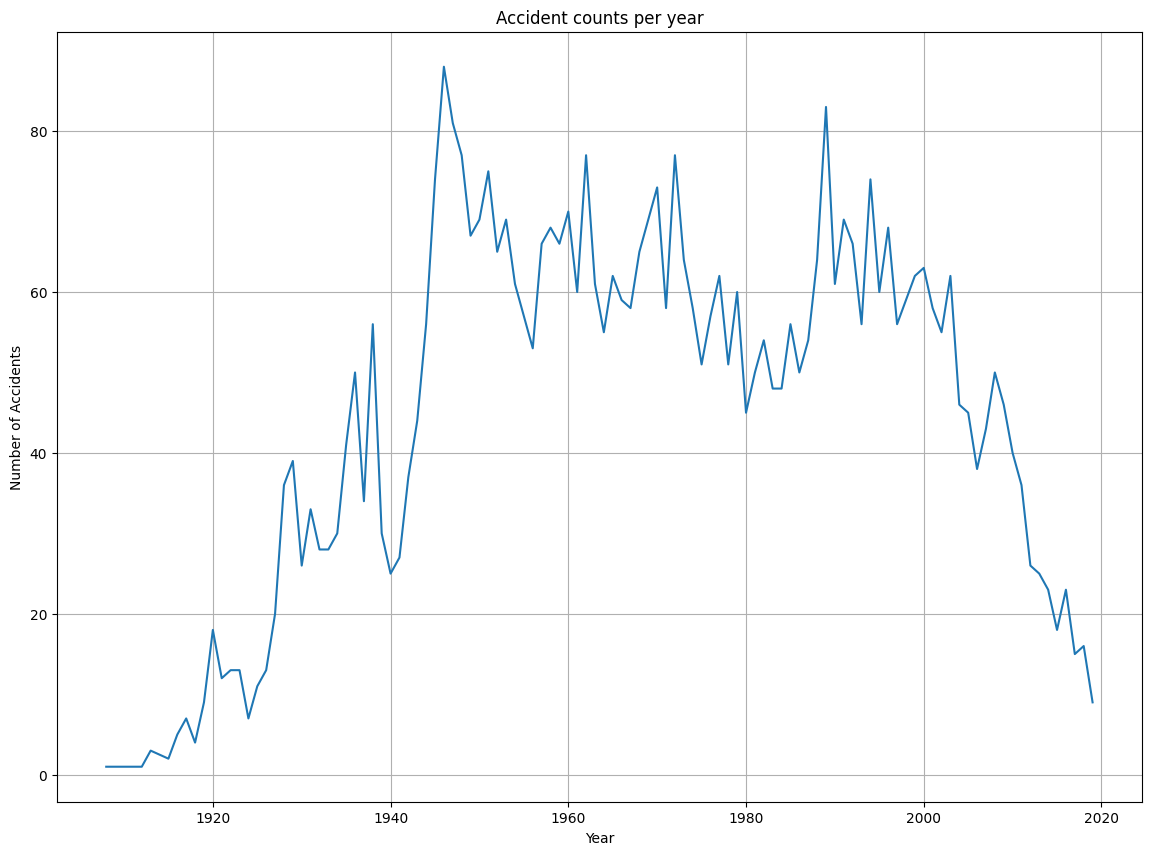

In [27]:
# accidents per year

accident_group = plane_df.groupby('Year', as_index=False).size()
#accident_group

plt.figure(figsize=(14, 10))
plt.grid(True)
plt.xlabel("Year")
plt.ylabel("Number of Accidents")
plt.title("Accident counts per year")
plt.plot(
    accident_group['Year'],
    accident_group['size']
)
plt.show()

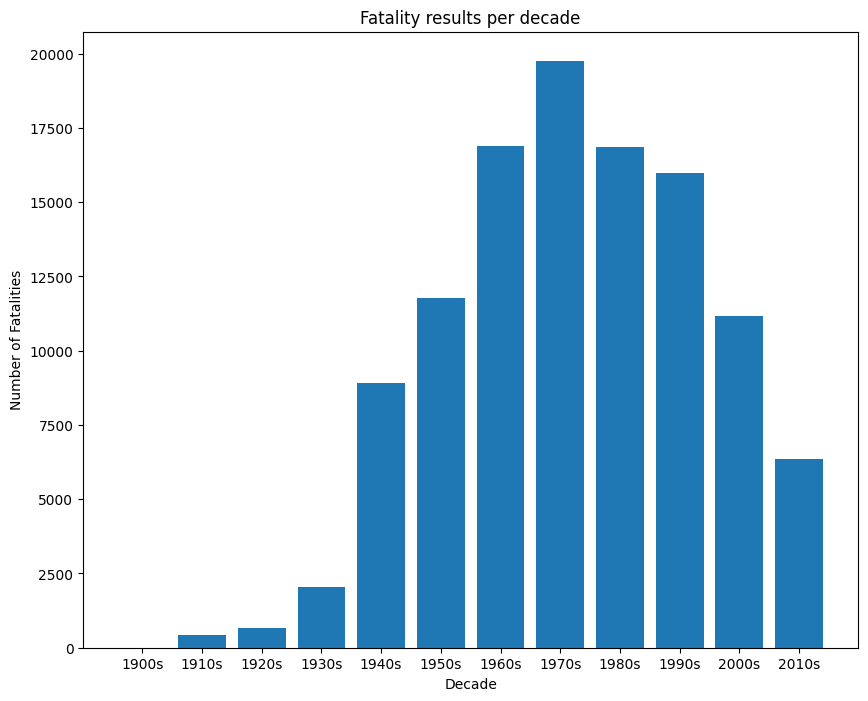

In [38]:
# fatalities per decade

fatal_decade = plane_df.groupby('Decade', as_index=False)['Fatalities'].sum()
#fatal_decade

plt.figure(figsize=(10, 8))
plt.xlabel("Decade")
plt.ylabel("Number of Fatalities")
plt.title("Fatality results per decade")
plt.bar(
    fatal_decade['Decade'],
    fatal_decade['Fatalities']
)
plt.show()

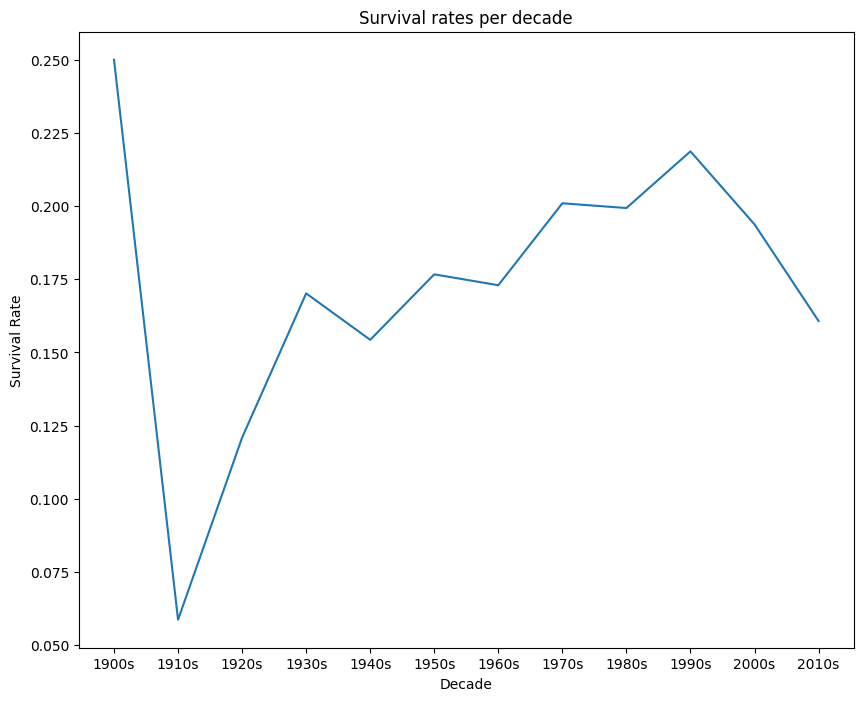

In [37]:
# survival rate per decade

survive_decade = plane_df.groupby('Decade', as_index=False)['Survival_Rate'].mean()
#survive_decade

plt.figure(figsize=(10, 8))
plt.xlabel("Decade")
plt.ylabel("Survival Rate")
plt.title("Survival rates per decade")
plt.plot(
    survive_decade['Decade'],
    survive_decade['Survival_Rate']
)
plt.show()

In [ ]:
y = groupby_df['Aboard']
x = groupby_df['Year']

plt.figure(figsize=(15, 8))
plt.grid(True)
plt.xlabel("Year")
plt.ylabel("Aboard")
plt.title("Aboard by Year")
plt.bar(x, y)
plt.show()

In [ ]:
y = groupby_df['Fatalities']
x = groupby_df['Year']

plt.figure(figsize=(15, 8))
plt.grid(True)
plt.xlabel("Year")
plt.ylabel("Fatalities")
plt.title("Fatalities by Year")
plt.bar(x, y, color='red')
plt.show()